## Mini projet : Estimation de la volatilité implicite (future) du S&P 500 sur 21 jours

On importe les données du S&P 500 et du VIX (indice de la peur) via yahoo finance

In [1]:
import yfinance as yf
SP500 = yf.download("^GSPC",start='2005-01-01',end='2024-12-31')
VIX = yf.download("^VIX",start='2005-01-01',end='2024-12-31')

SP500.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2005-01-03,1202.079956,1217.800049,1200.319946,1211.920044,1510800000
2005-01-04,1188.050049,1205.839966,1185.390015,1202.079956,1721000000
2005-01-05,1183.739990,1192.729980,1183.719971,1188.050049,1738900000
2005-01-06,1187.890015,1191.630005,1183.270020,1183.739990,1569100000
2005-01-07,1186.189941,1192.199951,1182.160034,1187.890015,1477900000


on regarde à quoi ressemble les données

In [2]:
VIX.head()

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2005-01-03,14.08,14.23,13.25,13.39,0
2005-01-04,13.98,14.45,13.93,14.01,0
2005-01-05,14.09,14.09,13.26,13.98,0
2005-01-06,13.58,14.09,13.33,14.09,0
2005-01-07,13.49,13.51,12.94,13.47,0


On crée une série pandas et on nettoie les données, et on les aplatit

In [3]:
import pandas as pd
df = pd.DataFrame({
    'close':SP500['Close'].squeeze(), #sqeeze apalit en 1 colonne
    'volume':SP500['Volume'].squeeze(),
    'vix':VIX['Close'].squeeze()
    }).dropna()
print(df.shape)
df.head()

(5032, 3)


,close,volume,vix
Date,,,
2005-01-03,1202.079956,1510800000,14.08
2005-01-04,1188.050049,1721000000,13.98
2005-01-05,1183.739990,1738900000,14.09
2005-01-06,1187.890015,1569100000,13.58
2005-01-07,1186.189941,1477900000,13.49


On veut déterminer la volatilité future du S&P500. 
on doit donc construire une colonne "volatilité"
On sait que la formule de la volatilité annualisée (un an a 252 jours ouvrés) sur par exemple 21 jours à pour formule : $\sqrt{252*\frac{1}{21}*\sum_{i=0}^{20} r_{t-i}^2} $
avec $r_t = \log(\frac{P_t}{P_{t-1}})$

--> On crée donc 2 colonnes :
- une colonne r_t (les rendements, et les rendements au carré)
- et une colonne VOL pour les volatilités, à l'aide de la formule

In [4]:
période = 21
import numpy as np
np.random.seed(42)
df['ret'] = np.log(df['close']).diff()
df['ret2'] = df['ret']**2
df['vol']= np.sqrt(252*df['ret2'].rolling(période).mean())
df=df.dropna()
df.tail()

,close,volume,vix,ret,ret2,vol
Date,,,,,,
2024-12-23,5974.069824,3593280000,16.780001,0.007261,5.271994e-05,0.129152
2024-12-24,6040.040039,1757720000,14.270000,0.010982,1.206094e-04,0.134103
2024-12-26,6037.589844,2904530000,14.730000,-0.000406,1.646258e-07,0.133703
2024-12-27,5970.839844,3159610000,15.950000,-0.011117,1.235945e-04,0.137728
2024-12-30,5906.939941,3433250000,17.400000,-0.010760,1.157706e-04,0.142071


On peut visualiser rapidement les colonnes importantes

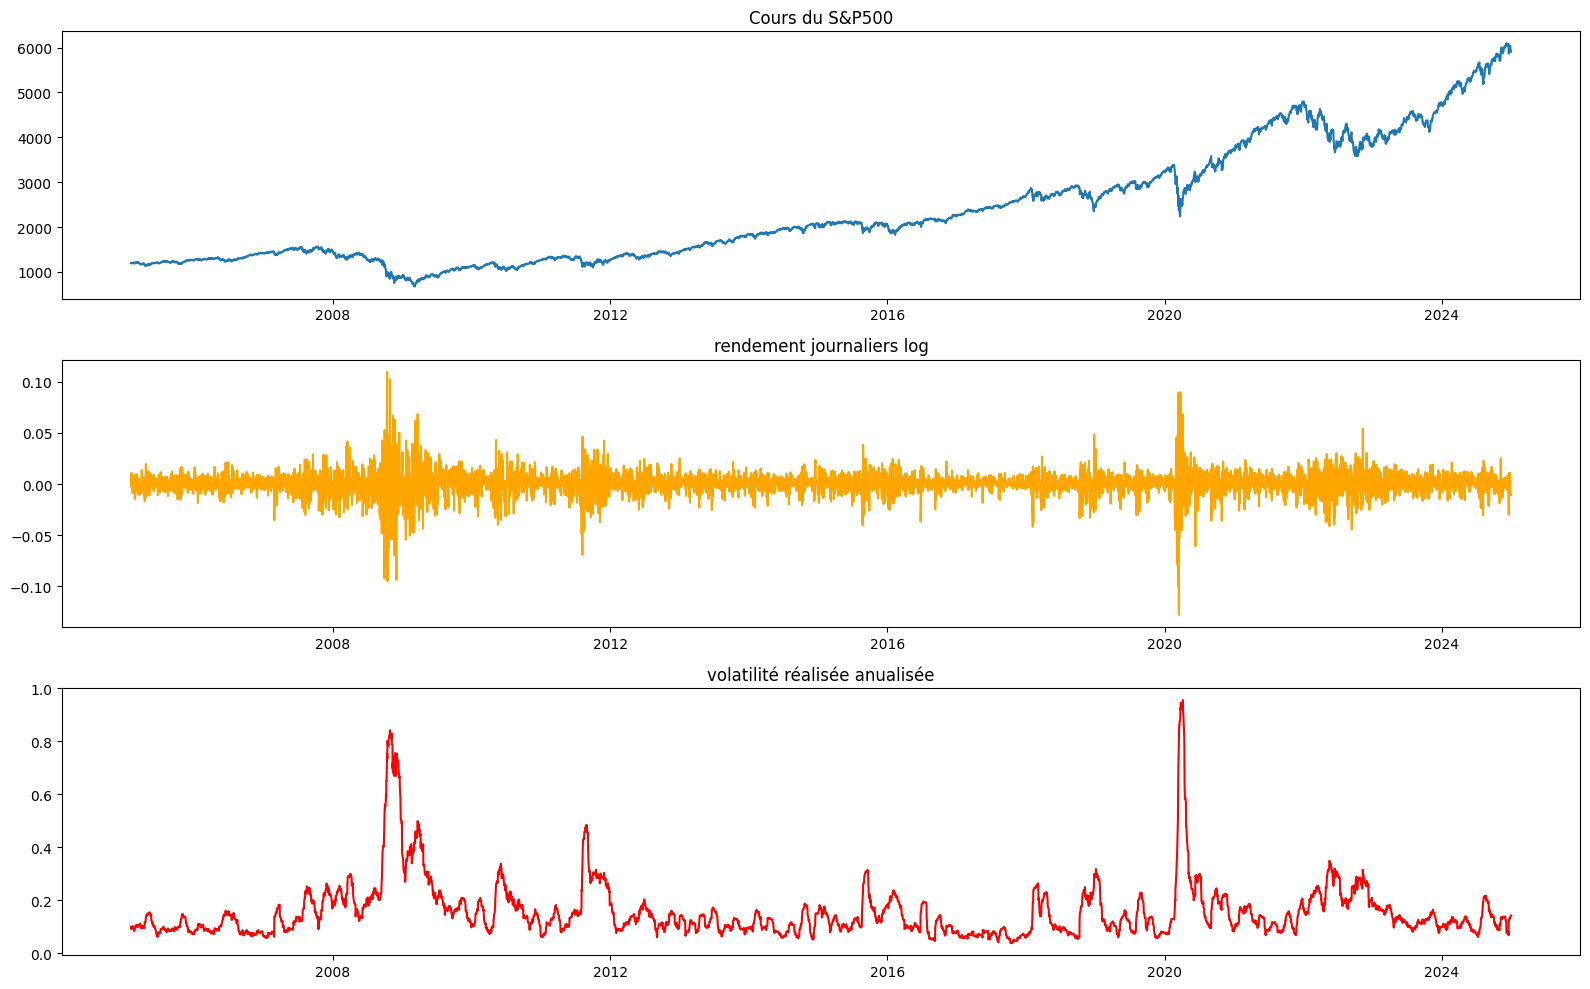

In [5]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(nrows=3,ncols=1, figsize=(16,10))

axes[0].plot(df['close'])
axes[0].set_title('Cours du S&P500')

axes[1].plot(df['ret'],color='orange')
axes[1].set_title('rendement journaliers log')

axes[2].plot(df['vol'],color='red')
axes[2].set_title('volatilité réalisée anualisée')
plt.tight_layout()
plt.show()

Décrivons un peu ces données

In [6]:
df[['ret','vol']].describe()

,ret,vol
count,5011.000000,5011.000000
mean,0.000320,0.157623
std,0.012122,0.110328
min,-0.127652,0.037966
25%,-0.004081,0.093123
50%,0.000720,0.128240
75%,0.005705,0.185682
max,0.109572,0.955642


on valide que l'autocrrelation de la vol est décroissante

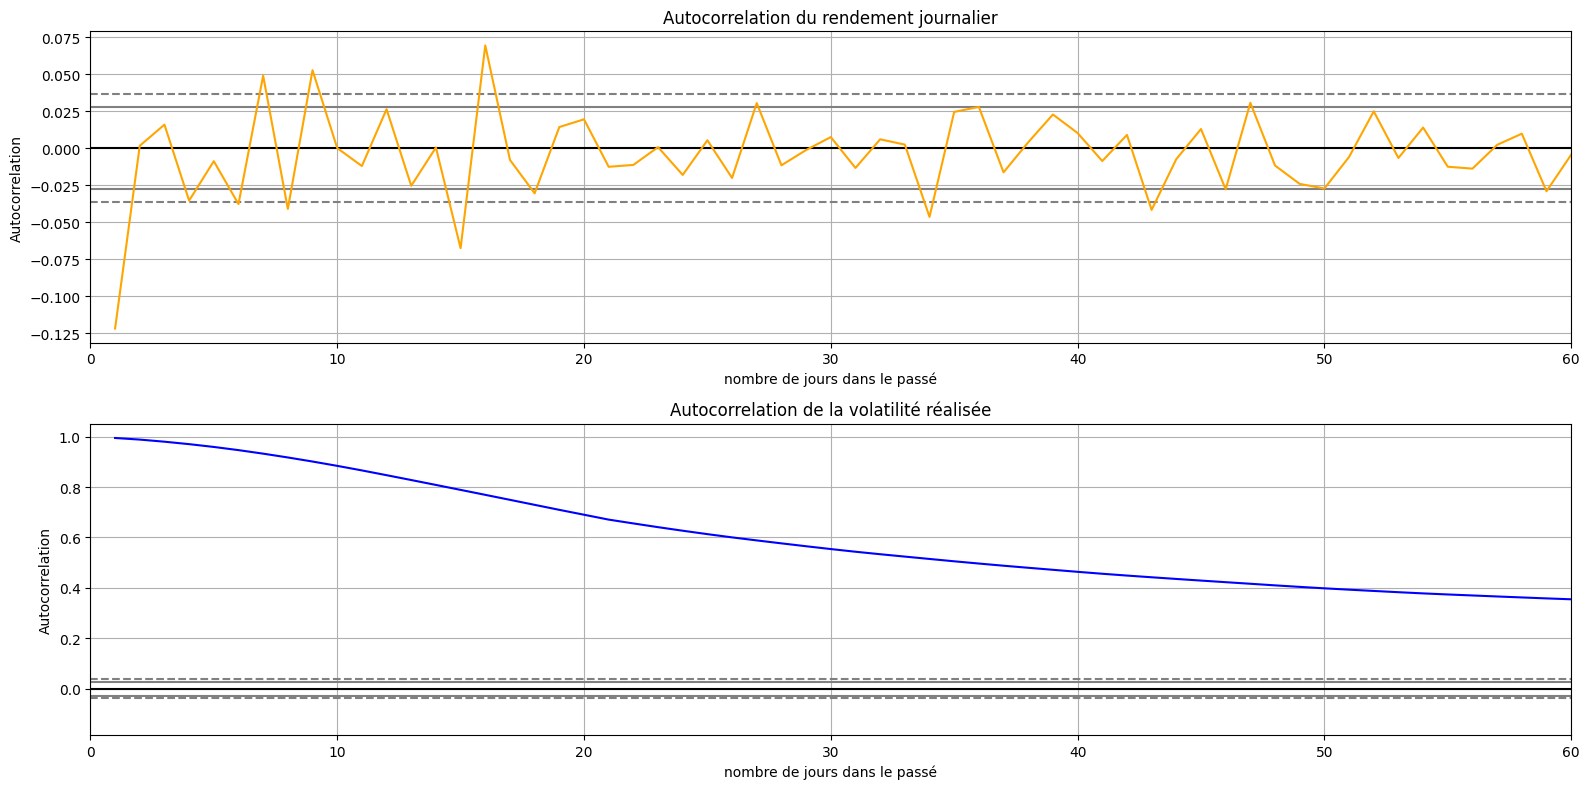

In [7]:
from pandas.plotting import autocorrelation_plot
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(16,8))

pd.plotting.autocorrelation_plot(df['ret'],ax=axes[0], color='orange')
axes[0].set_title("Autocorrelation du rendement journalier")
axes[0].set_xlabel("nombre de jours dans le passé")
axes[0].set_xlim(0,60)


pd.plotting.autocorrelation_plot(df['vol'],ax=axes[1],color='blue')
axes[1].set_title("Autocorrelation de la volatilité réalisée")
axes[1].set_xlabel("nombre de jours dans le passé")
axes[1].set_xlim(0,60)


plt.tight_layout()
plt.show()

Maintenant, on essaie de prédire la volatilité du lendemain (c'est à dire prédire $RV_{T+1}$) à partir des journées d'aujourd'hui.

Donc pour ça, on doit crée plein de colonnes de rendements, calculés à **différents horizons** (moyenne sur 5 jours, sur 21 jours, le vix, etc. mais décalés d'une journée avec shift(1) pour comparer hier et aujourd'hui)

In [8]:
horizons = pd.DataFrame(index=df.index)
horizons['vol'] = df["vol"]
horizons['vol_hier']= df['vol'].shift(1)
horizons['vol_lag5j']= df ['vol'].rolling(5).mean().shift(1)
horizons['vol_lag21j'] = df['vol'].rolling(21).mean().shift(1)
horizons['rendement'] = df['ret']
horizons['rendement_abs'] = df['ret'].abs()
horizons['vix'] = df['vix']
horizons['volume_log'] = np.log(df['volume']+1)
horizons['target'] = df['vol'].shift(-1) #la volatilité du lendemain
horizons = horizons.dropna()

print(f"le tableau de ces données est de taille {horizons.shape}")
horizons.head()

le tableau de ces données est de taille (4989, 9)


,vol,vol_hier,vol_lag5j,vol_lag21j,rendement,rendement_abs,vix,volume_log,target
Date,,,,,,,,,
2005-03-04,0.104032,0.099210,0.102873,0.096950,0.009578,0.009578,11.94,21.216021,0.103982
2005-03-07,0.103982,0.104032,0.103215,0.097195,0.002607,0.002607,12.26,21.121256,0.098196
2005-03-08,0.098196,0.103982,0.103069,0.097831,-0.004810,0.004810,12.40,21.144007,0.104336
2005-03-09,0.104336,0.098196,0.101487,0.097864,-0.010237,0.010237,12.70,21.256813,0.104520
2005-03-10,0.104520,0.104336,0.101951,0.098222,0.001854,0.001854,12.49,21.195779,0.103584


Ensuite, on sépare le jeu de données en 3 pour l'entrainenement (Train, Validation et Test) en les séparant par date (train les données les plus ancienne, Test les données les plus récentes)
On fait du 70%, 15%, 15% ici

In [9]:
n = len(horizons)
i_train = int(0.70*n)
i_validation = int(0.85*n)

train = horizons.iloc[:i_train] #les 70% les plus anciens
validation = horizons.iloc[i_train:i_validation] #les 15% entre 70 et 85% plus anciens
test = horizons.iloc[i_validation:] #les 15% plus récents

#On affiche les dates de début et de fin de chaque jeu
print(f'Le jeu "TRAIN" va de {train.index.min().date()} à {train.index.max().date()} avec {len(train)} observations\n')
print(f'Le jeu "VALIDATION" va de {validation.index.min().date()} à {validation.index.max().date()} avec {len(validation)} observations\n')
print(f'Le jeu "TEST" va de {test.index.min().date()} à {test.index.max().date()} avec {len(test)} observations\n')

Le jeu "TRAIN" va de 2005-03-04 à 2019-01-16 avec 3492 observations

Le jeu "VALIDATION" va de 2019-01-17 à 2022-01-04 avec 748 observations

Le jeu "TEST" va de 2022-01-05 à 2024-12-27 avec 749 observations



on centre-réduire le jeu de données, uniquement sur le jeu TRAIN car sion la moyenne contiendrait des données du futur.

In [10]:
from sklearn.preprocessing import StandardScaler
données = ['vol', 'vol_hier', 
           'vol_lag5j', 'vol_lag21j', 
           'rendement', 'rendement_abs', 
           'vix', 'volume_log']

#Normalisation du jeu TRAIN (et de la target)
norme_X = StandardScaler().fit(train[données]) 
norme_Y = StandardScaler().fit(train[['target']])

et avec la moyenne et l'écart type trouvé sur TRAIN, on centre-renduit aussi les 2 autres jeu de données

In [11]:
def normalisation(notre_df):
    X = norme_X.transform(notre_df[données])
    Y = norme_Y.transform(notre_df[['target']]).ravel() 
    #ravel permet d'applitir notre jeu
    return X, Y

on extrait les données normalisés, et on garde une copie de nos données non transformées pour après

In [12]:
X_train, Y_train = normalisation(train)
X_validation, Y_validation = normalisation(validation)
X_test, Y_test = normalisation(test)

#copies pour plus tard
Y_train_réel = train['target'].values
Y_validation_réel = validation['target'].values
Y_test_réel = test['target'].values


Ensuite, on construit les fenêtres glissantes (en jours) pour les modèles autre que MLP (du type CNN, etc). 

In [13]:
taille_fenetre = 60

def creation_fenetre(X,Y,durée=taille_fenetre):
    Xs, Ys =[],[]
    for i in range(durée,len(X)):
        #les 60 jours précédents l'instant i en matrice 2D
        Xs.append(X[i-durée:i])   
        # l'instant i qu'on veut calculer
        Ys.append(Y[i])          
    return np.array(Xs),np.array(Ys)

In [14]:
fenetre_X_train, fenetre_Y_train = creation_fenetre(X_train,Y_train)
fenetre_X_validation, fenetre_Y_validation = creation_fenetre(X_validation,Y_validation)
fenetre_X_test, fenetre_Y_test = creation_fenetre(X_test,Y_test)

print("on obtient 3 jeu de tenseurs avec : (nombre d'échantillon de fenêtre, taille fenêtre, nombre de colonnes dans 'Données')")
print(f'jeu Train : {fenetre_X_train.shape} vers sa cible de taille {fenetre_Y_train.shape}')
print(f'jeu Validation   : {fenetre_X_validation.shape} vers sa cible de taille {fenetre_Y_validation.shape}')
print(f'jeu Test  : {fenetre_X_test.shape} vers sa cible de taille {fenetre_Y_test.shape}')

on obtient 3 jeu de tenseurs avec : (nombre d'échantillon de fenêtre, taille fenêtre, nombre de colonnes dans 'Données')
jeu Train : (3432, 60, 8) vers sa cible de taille (3432,)
jeu Validation   : (688, 60, 8) vers sa cible de taille (688,)
jeu Test  : (689, 60, 8) vers sa cible de taille (689,)


Dans la suite de notre code, on a utilisé 3 métriques pour mesurer l'écart de volatilité réellement observée (y_reel) et celle prédite par chaque modele (y_predit)
On a fais des recherches sur internet pour les modèles

voici les 3 modèles : 

**RMSE = Root Mean Squared Error** : $\text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2}$
C'est l'erreur moyenne, exprimée dans  que la cible (ici, points de volatilité annualisée). Un RMSE de 0.05 signifie que le modèle se trompe en moyenne de ~5 points de vol.

**MAE = Mean Absolute Error** : $\text{MAE} = \frac{1}{n} \sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|$ c'est l'erreur moyenne en valeur absolue, même unité que la cible. En général plus robuste

**QLIKE = Quasi-Likelihood Loss** : $\text{QLIKE} = \frac{1}{n} \sum_{t=1}^{n} \left( \log \hat{\sigma}_t^{2} + \frac{\sigma_t^{2}}{\hat{\sigma}_t^{2}} \right)$ C'est la métrique spécifique à la prévision de volatilité, dérivée du *quasi-maximum likelihood* d'un modèle GARCH gaussien. 

On reviendra plus loin sur les résultats obtenus pour ces trois métriques afin de déterminer laquelle est la plus pertinente pour notre problème

On crée une fonction pour QLIKE

On crée donc une fonction qui calcule RMSE, MAE, QLIKE et qui retourne les valeurs leurs valeurs pour chaque modèle qu'on appel

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(name, y_réel, y_prédit, store):
    rmse = np.sqrt(mean_squared_error(y_réel, y_prédit))
    mae  = mean_absolute_error(y_réel, y_prédit)

    sigma2_réel   = np.maximum(y_réel, 1e-8) ** 2
    sigma2_prédit = np.maximum(y_prédit, 1e-8) ** 2
    ql = np.mean(np.log(sigma2_prédit) + sigma2_réel / sigma2_prédit)

    store[name] = {'RMSE': rmse, 'MAE': mae, 'QLIKE': ql}
    print(f'{name:20s}  RMSE={rmse:.4f}  MAE={mae:.4f}  QLIKE={ql:.4f}')
    return store

Avant de passer aux modèles de deep learning, on construit trois modèles de référence (baseline), du plus simple au plus élaboré, afin d'avoir un point de comparaison : si un réseau de neurones plus complexe ne fait pas mieux que ces baseline, il est inutile

Tout d'abord, on utilise une baseline dite naïve . On prédit que la volatilité de demain sera identique à celle d'aujourd'hui. C'est utile car la volatilité présente un fort effet de clustering : un jour de forte volatilité est souvent suivi d'un autre. Cette baseline triviale est donc étonnamment difficile à battre, et sert de plancher minimal

In [16]:
results = {}
predictions = {}
y_pred_naive = test['vol'].values   # vol courante comme prévision
evaluate('Naive', Y_test_réel, y_pred_naive, results)
predictions['Naive'] = y_pred_naive

Naive                 RMSE=0.0093  MAE=0.0055  QLIKE=-2.7740


On utilise ensuite une simple régression linéaire (modèle HAR-RV, publié par Corsi en 2009)  on combinnant trois horizons (1 jour, 5 jours, 21 jours). Cette combinaison capture mieux la dynamique de la volatilité qu'un seul lag, ce qui rend ce modèle pourtant simple très difficile à battre en pratique

In [17]:
from sklearn.linear_model import LinearRegression
#volatilité d'hier et sur les 5 et 21 derniers jours
regression_horizons = ['vol_hier', 'vol_lag5j', 'vol_lag21j'] 
regression = LinearRegression().fit(train[regression_horizons], train['target'])

#On évalue les 3 métriques
y_pred_regression = regression.predict(test[regression_horizons])
evaluate('regression', Y_test_réel, y_pred_regression, results)
predictions['regression'] = y_pred_regression

regression            RMSE=0.0130  MAE=0.0087  QLIKE=-2.7668


Sur cette période de test, la baseline naïve devance le modèle de regression linéaire sur les trois métriques, ce qui confirme le fort effet de clustering de la volatilité observé en partie 2. Cela nous invite à approfondir l'analyse une fois les modèles de deep learning évalués

On veut maintenant comparer plusieurs architectures de réseaux de neurones aux 2 baselines définies précédemment, pour voir si leur capacité à apprendre des relations non-linéaires permet de mieux prévoir la volatilité. 
On commence par définir des fonctions utilitaires communes, pour ne pas réécrire le même code d'entraînement à chaque nouvelle architecture testée.
- optimizer = Adam
- Epoch 80
- Pas de 1e-3


In [18]:
def entrainer(modele, X_entrée, Y_entrée, X_val, Y_val, 
                     epochs=80, taille_batch=64, pas=1e-3, verbose=1):
    #on cherche à minimiser la Mean Squarred Error
    modele.compile(optimizer=tf.keras.optimizers.legacy.Adam(pas), loss='mse', metrics=['mae'])
    #arrêter le modèle si pas d'amélioration après 10 epoch
    cb = [callbacks.EarlyStopping(patience=10, restore_best_weights=True)] 
    historique = modele.fit(X_entrée, Y_entrée, validation_data=(X_val, Y_val),
                            epochs=epochs, batch_size=taille_batch, callbacks=cb, verbose=verbose)
    return historique

#On de centre-reduit le modèle cible trouvé pour calculer les métriques
def denormaliser(y_normalisé):
    return norme_Y.inverse_transform(y_normalisé.reshape(-1, 1)).ravel()

def tracer(historique, titre):
    plt.figure(figsize=(8, 3))
    plt.plot(historique.history['loss'],     label='entraînement')
    plt.plot(historique.history['val_loss'], label='validation')
    plt.title(titre); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.show()

On crée une fonction pour moyenner les résultats, car sinon les résultats changent à chaque exécution

In [19]:
def entrainer_moyenne(modele_utilisé, X_entrée, Y_entrée, X_val, Y_val, X_eval, n_runs=5, **kwargs):
    predictions_runs = []
    for run in range(n_runs):
        print(f'  Run {run+1}/{n_runs}...')
        modele = modele_utilisé()
        entrainer(modele, X_entrée, Y_entrée, X_val, Y_val, verbose=1, **kwargs)
        pred = denormaliser(modele.predict(X_eval, verbose=1).ravel())
        predictions_runs.append(pred)
    return np.mean(predictions_runs, axis=0)

On commence par le modèle le plus simple : le MLP (perceptron multicouche). On construit l'architecture, on l'entraîne avec entrainer_modele, puis on évalue ses prédictions sur le jeu de test avec la fonction evaluate définie auparavant

In [20]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras import layers, Model, Sequential, callbacks

def MLP():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP ({} runs)...'.format(5))
y_pred_mlp = entrainer_moyenne(MLP,X_train, 
                               Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP', Y_test_réel, y_pred_mlp, results)
predictions['MLP'] = y_pred_mlp

Entraînement MLP (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.1366 - mae: 0.2242 - val_loss: 0.0900 - val_mae: 0.1713
Epoch 2/80
55/55 [==============================] - 0s 2ms/step - loss: 0.0620 - mae: 0.1510 - val_loss: 0.0766 - val_mae: 0.1472
Epoch 3/80
55/55 [==============================] - 0s 780us/step - loss: 0.0448 - mae: 0.1328 - val_loss: 0.0546 - val_mae: 0.1283
Epoch 4/80
55/55 [==============================] - 0s 735us/step - loss: 0.0364 - mae: 0.1224 - val_loss: 0.0562 - val_mae: 0.1174
Epoch 5/80
55/55 [==============================] - 0s 791us/step - loss: 0.0369 - mae: 0.1174 - val_loss: 0.0515 - val_mae: 0.1114
Epoch 6/80
55/55 [==============================] - 0s 777us/step - loss: 0.0317 - mae: 0.1117 - val_loss: 0.0464 - val_mae: 0.1100
Epoch 7/80
55/55 [==============================] - 0s 772us/step - loss: 0.0273 - mae: 0.1037 - val_loss: 0.0268 - val_mae: 0.0943
Epoch 8/80
55/55 [====================

In [21]:
def MLP0():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP0 ({} runs)...'.format(5))
y_pred_mlp0 = entrainer_moyenne(MLP0,X_train, Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP0', Y_test_réel, y_pred_mlp0, results)
predictions['MLP0'] = y_pred_mlp0


Entraînement MLP0 (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.1055 - mae: 0.2044 - val_loss: 0.0381 - val_mae: 0.1201
Epoch 2/80
55/55 [==============================] - 0s 711us/step - loss: 0.0155 - mae: 0.0848 - val_loss: 0.0240 - val_mae: 0.0945
Epoch 3/80
55/55 [==============================] - 0s 685us/step - loss: 0.0120 - mae: 0.0718 - val_loss: 0.0194 - val_mae: 0.0851
Epoch 4/80
55/55 [==============================] - 0s 689us/step - loss: 0.0110 - mae: 0.0682 - val_loss: 0.0184 - val_mae: 0.0816
Epoch 5/80
55/55 [==============================] - 0s 674us/step - loss: 0.0106 - mae: 0.0659 - val_loss: 0.0242 - val_mae: 0.0869
Epoch 6/80
55/55 [==============================] - 0s 706us/step - loss: 0.0105 - mae: 0.0661 - val_loss: 0.0184 - val_mae: 0.0826
Epoch 7/80
55/55 [==============================] - 0s 691us/step - loss: 0.0098 - mae: 0.0629 - val_loss: 0.0203 - val_mae: 0.0811
Epoch 8/80
55/55 [=================

In [22]:
def construire_MLP2():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP2 ({} runs)...'.format(5))
y_pred_mlp2 = entrainer_moyenne(construire_MLP2,X_train, Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP2', Y_test_réel, y_pred_mlp2, results)
predictions['MLP2'] = y_pred_mlp2

Entraînement MLP2 (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.2933 - mae: 0.2824 - val_loss: 0.1169 - val_mae: 0.1903
Epoch 2/80
55/55 [==============================] - 0s 889us/step - loss: 0.0583 - mae: 0.1538 - val_loss: 0.0532 - val_mae: 0.1464
Epoch 3/80
55/55 [==============================] - 0s 892us/step - loss: 0.0501 - mae: 0.1399 - val_loss: 0.0513 - val_mae: 0.1345
Epoch 4/80
55/55 [==============================] - 0s 1ms/step - loss: 0.0426 - mae: 0.1288 - val_loss: 0.0375 - val_mae: 0.1127
Epoch 5/80
55/55 [==============================] - 0s 853us/step - loss: 0.0420 - mae: 0.1199 - val_loss: 0.0351 - val_mae: 0.1106
Epoch 6/80
55/55 [==============================] - 0s 863us/step - loss: 0.0335 - mae: 0.1147 - val_loss: 0.0482 - val_mae: 0.1230
Epoch 7/80
55/55 [==============================] - 0s 854us/step - loss: 0.0295 - mae: 0.1120 - val_loss: 0.0339 - val_mae: 0.1134
Epoch 8/80
55/55 [===================

In [23]:
def MLP20():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP20 ({} runs)...'.format(5))
y_pred_mlp20 = entrainer_moyenne(MLP20,X_train, Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP20', Y_test_réel, y_pred_mlp20, results)
predictions['MLP20'] = y_pred_mlp20


Entraînement MLP20 (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.0895 - mae: 0.1925 - val_loss: 0.0312 - val_mae: 0.1131
Epoch 2/80
55/55 [==============================] - 0s 818us/step - loss: 0.0135 - mae: 0.0778 - val_loss: 0.0214 - val_mae: 0.0890
Epoch 3/80
55/55 [==============================] - 0s 822us/step - loss: 0.0106 - mae: 0.0653 - val_loss: 0.0182 - val_mae: 0.0863
Epoch 4/80
55/55 [==============================] - 0s 811us/step - loss: 0.0098 - mae: 0.0628 - val_loss: 0.0163 - val_mae: 0.0752
Epoch 5/80
55/55 [==============================] - 0s 815us/step - loss: 0.0089 - mae: 0.0583 - val_loss: 0.0169 - val_mae: 0.0749
Epoch 6/80
55/55 [==============================] - 0s 832us/step - loss: 0.0089 - mae: 0.0591 - val_loss: 0.0167 - val_mae: 0.0746
Epoch 7/80
55/55 [==============================] - 0s 806us/step - loss: 0.0086 - mae: 0.0576 - val_loss: 0.0167 - val_mae: 0.0740
Epoch 8/80
55/55 [================

In [24]:
def MLP3():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP3 ({} runs)...'.format(5))
y_pred_mlp3 = entrainer_moyenne(MLP3,X_train, Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP3', Y_test_réel, y_pred_mlp3, results)
predictions['MLP3'] = y_pred_mlp3

Entraînement MLP3 (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.2084 - mae: 0.2750 - val_loss: 0.0589 - val_mae: 0.1474
Epoch 2/80
55/55 [==============================] - 0s 831us/step - loss: 0.0691 - mae: 0.1727 - val_loss: 0.0402 - val_mae: 0.1304
Epoch 3/80
55/55 [==============================] - 0s 831us/step - loss: 0.0597 - mae: 0.1578 - val_loss: 0.0520 - val_mae: 0.1272
Epoch 4/80
55/55 [==============================] - 0s 831us/step - loss: 0.0526 - mae: 0.1472 - val_loss: 0.0598 - val_mae: 0.1270
Epoch 5/80
55/55 [==============================] - 0s 848us/step - loss: 0.0487 - mae: 0.1407 - val_loss: 0.0326 - val_mae: 0.1065
Epoch 6/80
55/55 [==============================] - 0s 824us/step - loss: 0.0463 - mae: 0.1360 - val_loss: 0.0339 - val_mae: 0.1097
Epoch 7/80
55/55 [==============================] - 0s 836us/step - loss: 0.0446 - mae: 0.1302 - val_loss: 0.0485 - val_mae: 0.1268
Epoch 8/80
55/55 [=================

In [25]:
def MLP30():
    return Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1),
    ])

print('Entraînement MLP30 ({} runs)...'.format(5))
y_pred_mlp30 = entrainer_moyenne(MLP30,X_train, Y_train,X_validation, Y_validation,X_test,n_runs=5)
evaluate('MLP30', Y_test_réel, y_pred_mlp30, results)
predictions['MLP30'] = y_pred_mlp30

Entraînement MLP30 (5 runs)...
  Run 1/5...
Epoch 1/80
55/55 [==============================] - 0s 2ms/step - loss: 0.1929 - mae: 0.2230 - val_loss: 0.0663 - val_mae: 0.1488
Epoch 2/80
55/55 [==============================] - 0s 803us/step - loss: 0.0165 - mae: 0.0826 - val_loss: 0.0288 - val_mae: 0.0931
Epoch 3/80
55/55 [==============================] - 0s 793us/step - loss: 0.0123 - mae: 0.0701 - val_loss: 0.0215 - val_mae: 0.0934
Epoch 4/80
55/55 [==============================] - 0s 804us/step - loss: 0.0102 - mae: 0.0650 - val_loss: 0.0173 - val_mae: 0.0773
Epoch 5/80
55/55 [==============================] - 0s 787us/step - loss: 0.0097 - mae: 0.0624 - val_loss: 0.0198 - val_mae: 0.0807
Epoch 6/80
55/55 [==============================] - 0s 799us/step - loss: 0.0093 - mae: 0.0613 - val_loss: 0.0211 - val_mae: 0.0824
Epoch 7/80
55/55 [==============================] - 0s 827us/step - loss: 0.0090 - mae: 0.0598 - val_loss: 0.0207 - val_mae: 0.0792
Epoch 8/80
55/55 [================

On va ensuite aborder le modèle 1D-CNN, pour voir si la détection de motifs locaux dans la séquence (pics, retournements) apporte un gain par rapport au MLP. Contrairement à ce dernier, le CNN reçoit l'historique sous forme de séquence (les 60 derniers jours de features) plutôt qu'un simple vecteur à un instant donné

In [26]:
def CNN():
    return Sequential([
        layers.Input(shape=(taille_fenetre, X_train.shape[1])),
        layers.Conv1D(32, kernel_size=5, activation='relu', padding='causal'),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='causal'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])

print('Entraînement 1D-CNN (5 runs)...')
y_pred_cnn_complet = entrainer_moyenne(CNN,fenetre_X_train, fenetre_Y_train,fenetre_X_validation, 
                                       fenetre_Y_validation,fenetre_X_test,n_runs=5)
# Les 60 premiers jours du test n'ont pas de séquence (pas assez d'historique)
y_pred_cnn = np.concatenate([np.full(taille_fenetre, np.nan), y_pred_cnn_complet])
masque = ~np.isnan(y_pred_cnn)
evaluate('1D-CNN', Y_test_réel[masque], y_pred_cnn[masque], results)
predictions['1D-CNN'] = y_pred_cnn

Entraînement 1D-CNN (5 runs)...
  Run 1/5...
Epoch 1/80
54/54 [==============================] - 0s 4ms/step - loss: 0.4509 - mae: 0.4091 - val_loss: 1.2821 - val_mae: 0.5414
Epoch 2/80
54/54 [==============================] - 0s 4ms/step - loss: 0.2481 - mae: 0.3100 - val_loss: 0.8269 - val_mae: 0.4724
Epoch 3/80
54/54 [==============================] - 0s 4ms/step - loss: 0.1639 - mae: 0.2728 - val_loss: 0.6974 - val_mae: 0.4810
Epoch 4/80
54/54 [==============================] - 0s 3ms/step - loss: 0.1376 - mae: 0.2531 - val_loss: 0.6117 - val_mae: 0.4450
Epoch 5/80
54/54 [==============================] - 0s 3ms/step - loss: 0.1193 - mae: 0.2386 - val_loss: 0.5191 - val_mae: 0.4163
Epoch 6/80
54/54 [==============================] - 0s 3ms/step - loss: 0.1123 - mae: 0.2264 - val_loss: 0.6477 - val_mae: 0.4781
Epoch 7/80
54/54 [==============================] - 0s 3ms/step - loss: 0.1081 - mae: 0.2264 - val_loss: 0.4070 - val_mae: 0.3750
Epoch 8/80
54/54 [===========================

On veut maintenant comparer l'ensemble des modèles testés (baselines et deep learning) sur une vue d'ensemble, pour identifier clairement lequel se distingue selon chaque métrique. On commence par regrouper tous les résultats dans un tableau unique, trié par RMSE croissant

In [27]:
tableau_resultats = pd.DataFrame(results).T.round(4)
tableau_resultats.sort_values('RMSE').round(4)

,RMSE,MAE,QLIKE
Naive,0.0093,0.0055,-2.7740
MLP20,0.0095,0.0063,-2.7743
MLP30,0.0096,0.0061,-2.7740
MLP0,0.0097,0.0064,-2.7736
MLP,0.0099,0.0067,-2.7736
MLP3,0.0113,0.0078,-2.7712
MLP2,0.0114,0.0071,-2.7723
regression,0.0130,0.0087,-2.7668
1D-CNN,0.0301,0.0224,-2.7644


Ce tableau confirme que le classement des modèles change selon la métrique utilisée. Sur RMSE et MAE, la baseline naïve reste la plus performante, suivie du MLP. Sur QLIKE en revanche, le 1D-CNN prend la tête et est le plus petit, devançant même la baseline naïve

On visualise ensuite ce tableau sous forme de graphiques en barres, un par métrique, pour repérer plus facilement les écarts entre modèles et voir si le classement change selon la métrique choisie

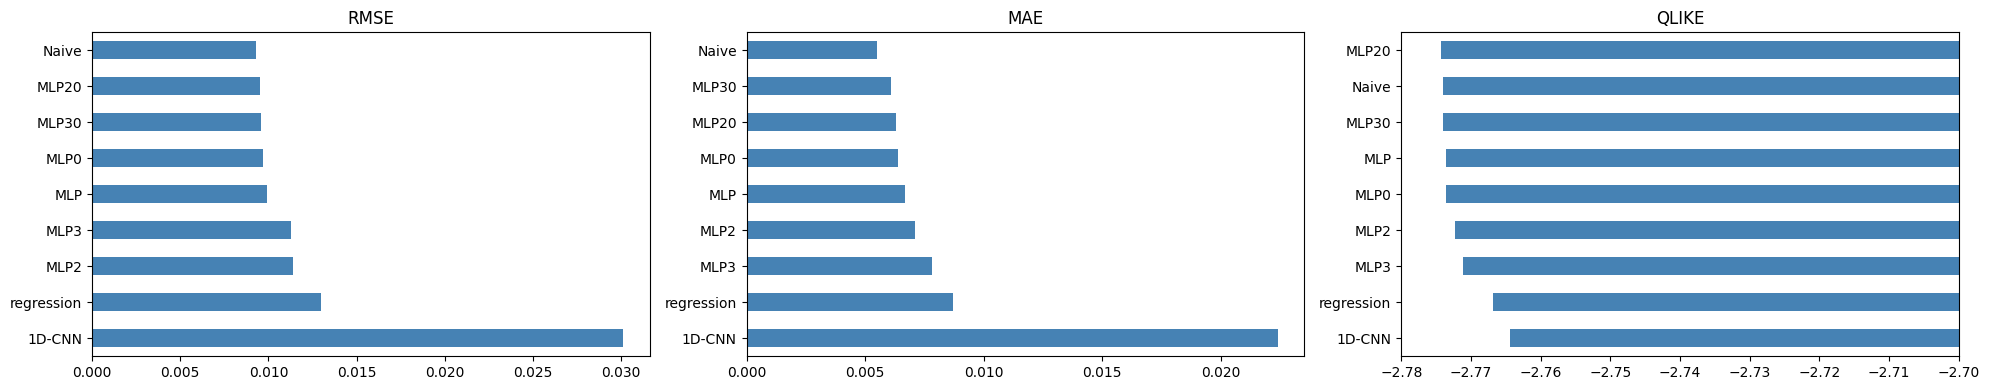

In [28]:
fig, ax = plt.subplots(1,3, figsize=(20,4))

for i, metrique in enumerate(['RMSE', 'MAE', 'QLIKE']):
    tableau_resultats[metrique].sort_values().plot(kind='barh', ax=ax[i], color='steelblue')
    ax[i].set_title(metrique)
    ax[i].invert_yaxis()

ax[2].set_xlim(-2.78, -2.70)
plt.tight_layout()
plt.show()


**Interpration des résultats obtenus :** en comparant les modèles testés, on observe que la baseline naïve reste la plus performante sur RMSE et MAE, ce qui confirme la difficulté à battre une référence aussi simple sur ce type de série. 

Le 1D-CNN se distingue toutefois nettement sur le QLIKE, où ils obtiennent les meilleurs scores de l'ensemble des modèles, y compris devant la baseline naïve. Cela suggère que ce modèle, bien qu'un peu moins précis en moyenne, sous-estiment moins souvent les pics de volatilité, ce qui est précisément le comportement recherché en gestion des risques. 

On trace ensuite les prédictions de quelques modèles représentatifs face à la vraie volatilité sur la période de test, pour visualiser concrètement où chaque modèle se rapproche ou s'éloigne de la réalité, notamment sur les pics

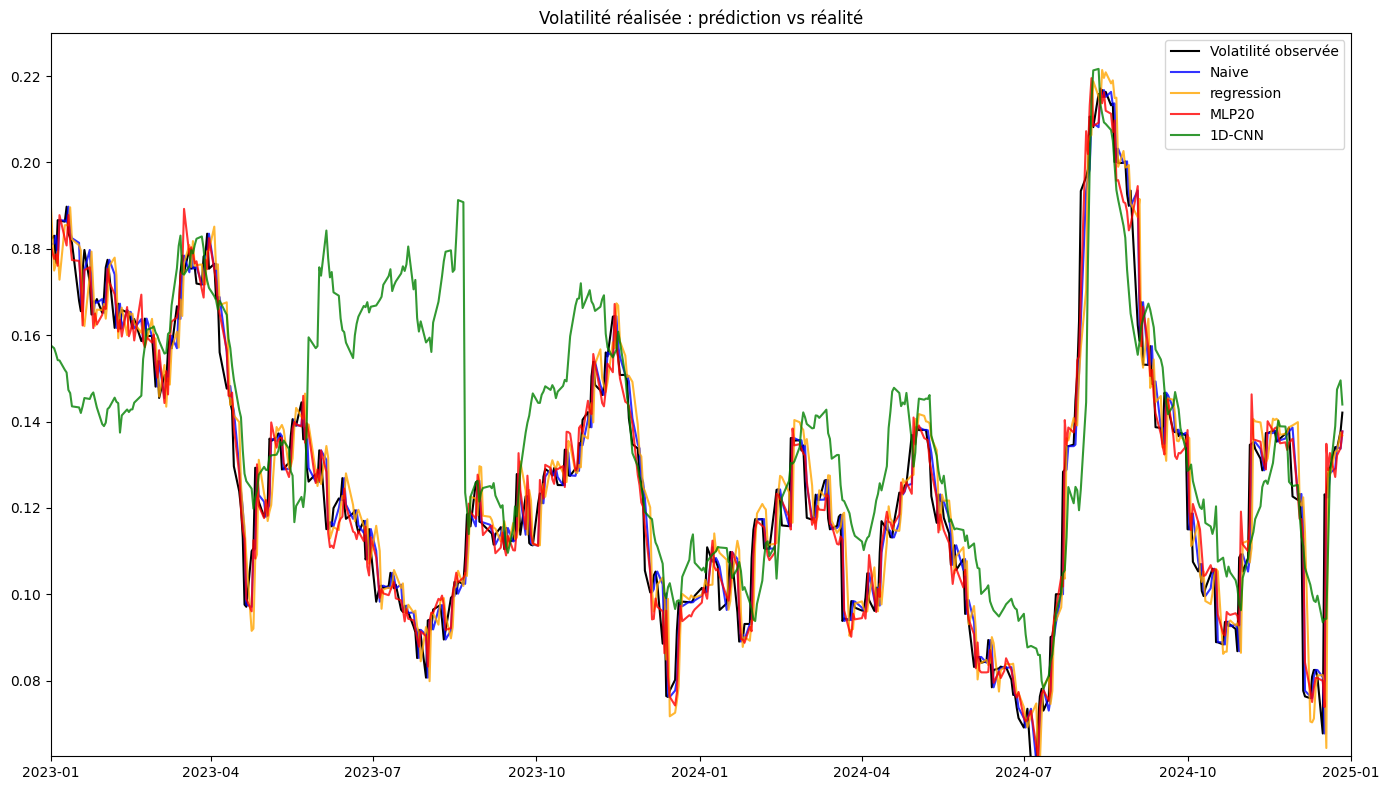

In [29]:
fig, ax = plt.subplots(figsize=(14, 8))
couleurs={'Naive':'blue','regression':'orange','MLP20':'red','1D-CNN':'green'}
ax.plot(test.index, Y_test_réel, label='Volatilité observée', color='black', lw=1.5)
for nom in ['Naive', 'regression', 'MLP20','1D-CNN']:
    if nom in predictions:
        ax.plot(test.index, predictions[nom], label=nom, alpha=0.8,color=couleurs.get(nom))
ax.set_title('Volatilité réalisée : prédiction vs réalité')
ax.set_xlim(pd.Timestamp('2023-01-01'),pd.Timestamp('2025-01-01'))
ax.set_ylim(0.0625,0.23)
ax.legend(); plt.tight_layout(); plt.show()

On voit plus que le modèle de regression et modèle Naive suivent fidèlement la volatilité observée, de même que MLP20, y compris sur les pics marquants (mai 2022, octobre 2022, fin 2024). Le 1D-CNN, à l'inverse, décroche nettement : il surestime fortement la volatilité autour de mi-2023 sans justification apparente dans les données, ce qui explique ses mauvais scores sur l'ensemble des métriques

**Conclusion générale sur le choix des modèles** : 

On peut en conclure que :

Le modèle de "regression" est traditionnellement très dur à battre, car il capture directement la structure de mémoire longue de la volatilité (composantes journalière, hebdomadaire, mensuelle). Néanmoins, on voit que certains de nos modèles MLP (3 couches 128,64,32 avec dropout notamment) arrivent à le battre.

Le modèle Naïf est, paradoxalement, extremement dur à battre. Il est celui qui minimize le plus le MAE, et le RMSE, et arrive en 2ème position sur le QLIKE. 

le modèle 1D-CNN est certes moins précis en moyenne sur le RMSE et MAE, et même le QLIKE, car il a un biais de surestimation systématique (par exemple il surestime la volatilité avec un pic en 2023), ce qui en fait paradoxalement le meilleur modèle d'un point de vue économique : il est plus conservateur, donc plus prudent pour la couverture de risque. C'est un modèle qui est souvent préféré, de même que d'autres modèles que l'on a pas implémenté dans ce projet et qui sont spécifique à l'étude de la volatilité (LSTM, GRU, GARCH(1,1)...)